# Cost Function Components Visualization

Visualize the different components of the optimization cost function:
- Left panel: CRRA utility for different risk aversion parameters (gamma)
- Right panel: Sigmoid wealth penalty for different steepness parameters (k)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

In [2]:
# CRRA utility function
def crra_utility(x, gamma, normalize=False):
    """
    CRRA utility as a function of normalized consumption x = C / C_floor
    
    U(x) = (x^(1-gamma) - 1) / (1 - gamma)
    
    Parameters
    ----------
    x : array-like
        Normalized consumption (C / C_floor)
    gamma : float
        Risk aversion coefficient (gamma > 1)
    normalize : bool
        If True, normalize utility so lim_(x->inf) U(x) = 1
    """
    utility = (x**(1 - gamma) - 1) / (1 - gamma)
    if normalize and gamma > 1:
        utility = utility * (gamma - 1)
    return utility

# Sigmoid wealth penalty
def sigmoid_penalty(wealth, steepness):
    """
    Sigmoid-based wealth penalty
    
    Penalty(W) = -sigmoid(k * W)
    
    Parameters
    ----------
    wealth : array-like
        Wealth levels
    steepness : float
        Steepness parameter k
    """
    sigmoid = 1 / (1 + np.exp(-steepness * wealth))
    return -sigmoid

Figure saved to: d:\MADS-Project\Figs\Scripts\..\cost_function_components.png


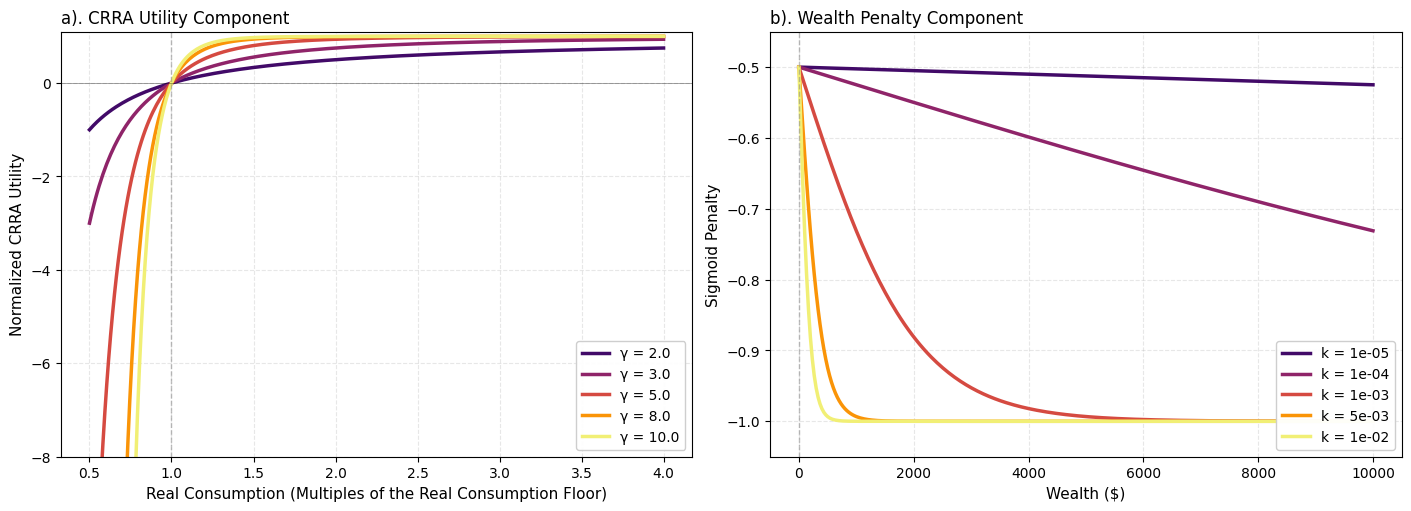

In [19]:
# Create figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# --- LEFT PANEL: CRRA Utility for different gammas ---

# Normalized consumption range (C / C_floor)
x_range = np.linspace(0.5, 4.0, 300)

# Risk aversion coefficients to plot
gammas = [2.0, 3.0, 5.0, 8.0, 10.0]

# Use inferno colormap (similar to other scripts in this folder)
colors_crra = cm.inferno(np.linspace(0.2, 0.95, len(gammas)))

for gamma, color in zip(gammas, colors_crra):
    utility = crra_utility(x_range, gamma, normalize=True)
    ax1.plot(x_range, utility, linewidth=2.5, label=f'γ = {gamma}', color=color)

ax1.set_xlabel('Real Consumption (Multiples of the Real Consumption Floor)', fontsize=11)
ax1.set_ylabel('Normalized CRRA Utility', fontsize=11)
ax1.set_title('a). CRRA Utility Component', loc='left', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Subsistence (x=1)')
ax1.set_ylim(-8, 1.1)

# --- RIGHT PANEL: Sigmoid Wealth Penalty for different k values ---

# Wealth range (normalized, e.g., as multiples of consumption floor)
wealth_range = np.linspace(0, 10_000, 300)

# Steepness parameters to plot
k_values = [1e-5, 1e-4, 1e-3, 5e-3, 1e-2]

# Use inferno colormap
colors_k = cm.inferno(np.linspace(0.2, 0.95, len(k_values)))

for k, color in zip(k_values, colors_k):
    penalty = sigmoid_penalty(wealth_range, k)
    ax2.plot(wealth_range, penalty, linewidth=2.5, label=f'k = {k:.0e}', color=color)

ax2.set_xlabel('Wealth ($)', fontsize=11)
ax2.set_ylabel('Sigmoid Penalty', fontsize=11)
ax2.set_title('b). Wealth Penalty Component', loc='left', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Zero wealth')
ax2.set_ylim(-1.05, -0.45)

# Save figure
script_dir = os.path.dirname(os.path.abspath('cost_function_components.ipynb'))
output_path = os.path.join(script_dir, '..', 'cost_function_components.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to: {output_path}')
plt.show()

Figure saved to: d:\MADS-Project\Figs\Scripts\..\cost_function_components.png


<Figure size 640x480 with 0 Axes>